<a href="https://colab.research.google.com/github/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/main/Notebook/02_Defini%C3%A7%C3%A3o_Target_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 2: Preparação de Dados, Definição do Target e Unificação das Bases**

Neste segundo notebook, avançamos da fase exploratória inicial para a estruturação da Base de Modelagem (ABT - Analytical Base Table). O objetivo principal é consolidar o histórico do cliente, tratar inconsistências estruturais e definir com precisão a variável resposta (*Target*) que identificará os clientes como **Bons** ou **Maus pagadores**.

Ao final, a base consolidada será salva para uso no Notebook 3,
onde faremos a preparação para os algoritmos e a modelagem.

In [1]:
# 1. Baixa o arquivo zip direto do GitHub (usando ?raw=true) para o ambiente do Colab
!wget -O /content/BaseDadosFase2.zip https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip?raw=true

# 2. Descompacta o arquivo em uma pasta chamada 'dados_extraidos'
!unzip -o /content/BaseDadosFase2.zip -d dados_extraidos

--2026-10-09 20:12:10--  https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/blob/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip?raw=true
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/raw/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip [following]
--2026-10-09 20:12:10--  https://github.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/raw/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/fernandinhaalmeida84/Tech_Challenge_Fase_2/1462573e4453793ed0c8e218b35ece6ce166caee/Data/Raw/BaseDadosFase2.zip [following]
--2026-10-09 20:12:11--  https://raw.githubusercontent.com/fernandinhaalmeida8

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', None)

# 1. Caminhos locais para os arquivos extraídos do Zip do GitHub
path_cad = Path('/content/dados_extraidos/application_record.csv')
path_cred = Path('/content/dados_extraidos/credit_record.csv')

if path_cad.exists() and path_cred.exists():
    print("✅ CSVs locais detectados. Carregando e aplicando tratamentos...")
    df_cadastro = pd.read_csv(path_cad)
    df_credito = pd.read_csv(path_cred)

    # Tratamentos equivalentes aplicados no Notebook 01
    df_cadastro['Idade'] = (-df_cadastro['DAYS_BIRTH'] / 365.25).astype(int)
    df_cadastro['Anos_Trabalhados'] = df_cadastro['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else -x / 365.25)
    df_cadastro['CNT_FAM_MEMBERS_TRATADO'] = df_cadastro['CNT_FAM_MEMBERS'].clip(upper=5)
else:
    raise FileNotFoundError("❌ Os arquivos extraídos não foram localizados na pasta /content/dados_extraidos/.")

# 2. Definição da função auxiliar indispensável para as próximas análises
def analisar_taxas_por_categoria(df, coluna, nome_coluna):
    # Garantindo que as colunas necessárias existam para a agregação
    df_temp = df.copy()
    if 'BOM_PAGADOR_EXCLUSIVO' not in df_temp.columns:
        df_temp['BOM_PAGADOR_EXCLUSIVO'] = ((df_temp['Inad90'] == 0) & (df_temp['Inad30'] == 0)).astype(int)
    if 'PERMISSIVO_EXCLUSIVO' not in df_temp.columns:
        df_temp['PERMISSIVO_EXCLUSIVO'] = ((df_temp['Inad30'] == 1) & (df_temp['Inad90'] == 0)).astype(int)

    analise = df_temp.groupby(coluna, observed=False).agg(
        Total_Clientes=('ID', 'count'),
        Taxa_Bom_Pagador_Pct=('BOM_PAGADOR_EXCLUSIVO', lambda x: x.mean() * 100),
        Taxa_Permissivo_Pct=('PERMISSIVO_EXCLUSIVO', lambda x: x.mean() * 100),
        Taxa_Mau_Pagador_Pct=('Inad90', lambda x: x.mean() * 100)
    ).reset_index()

    print(f"\n=== ANÁLISE POR {nome_coluna.upper()} ===")
    display(analise.round(2))

print(f"✅ Base de cadastros carregada: {df_cadastro.shape}")
print(f"✅ Base de créditos carregada: {df_credito.shape}")

✅ CSVs locais detectados. Carregando e aplicando tratamentos...
✅ Base de cadastros carregada: (438557, 21)
✅ Base de créditos carregada: (1048575, 3)


In [3]:
print('Cadastro:', df_cadastro.shape, df_cadastro.columns.tolist())
print('Crédito :', df_credito.shape, df_credito.columns.tolist())

Cadastro: (438557, 21) ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'Idade', 'Anos_Trabalhados', 'CNT_FAM_MEMBERS_TRATADO']
Crédito : (1048575, 3) ['ID', 'MONTHS_BALANCE', 'STATUS']


```markdown
#**1. Definição dos Targets**

A escolha do critério é uma decisão de negócio, não estatística.

**Critério Inad30:**

Este critério classifica como Inad30 qualquer cliente que tenha registrado, em pelo menos um mês, um status (1, 2, 3, 4 ou 5). Aqui é mais conservador quanto ao critério risco, para que qualquer sinal de atraso, mesmo que pequeno, é tratado como evidência suficiente de comportamento de pagamento problemático, já que atrasos leves recorrentes tendem a preceder atrasos mais graves.

**Critério Inad90:**

são os clientes com atraso superior a 90 dias (Status 3, 4 ou 5) no histórico, e o restante como Bom Pagador (0). O critério Inad90 é bem menos rígido e deixa a classe de Inad90 bem mais rara, o que torna o problema fortemente desbalanceado.
```

In [26]:
# 1. Critério Padrão (Atraso > 90 dias): Status 3, 4, 5
df_credito['Inad90'] = df_credito['STATUS'].isin(['3', '4', '5']).astype(int)

# 2. Critério Permissivo (Atraso >= 30 dias): Status 1, 2, 3, 4, 5
df_credito['Inad30'] = df_credito['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

# Agrupando por ID para pegar o pior status histórico de cada cliente sob cada critério
df_target_padrao = df_credito.groupby('ID')['Inad90'].max().reset_index()
df_target_permissivo = df_credito.groupby('ID')['Inad30'].max().reset_index()

# Unificando os targets temporariamente em um único dataframe de referência
df_target = pd.merge(df_target_padrao, df_target_permissivo, on='ID', how='inner')

# Criando o indicador de Exclusivo (Apenas 30-60 dias de atraso)
df_target['PERMISSIVO'] = ((df_target['Inad30'] == 1) & (df_target['Inad90'] == 0)).astype(int)

# Definindo o perfil completo do cliente na base de crédito de forma mutuamente exclusiva
def classificar_historico(row):
    if row['Inad90'] == 1:
        return 'Inad90 (> 90d)'
    elif row['Inad30'] == 1:
        return 'Inad30 (30-60d)'
    else:
        return 'Bom Pagador (Sem atrasos)'

df_target['GRUPO_CREDITO'] = df_target.apply(classificar_historico, axis=1)

In [9]:
print("=== DISTRIBUIÇÃO DOS GRUPOS NA BASE DE CRÉDITO (MÁXIMO HISTÓRICO POR ID) ===")
contagem_inicial = df_target['GRUPO_CREDITO'].value_counts()
proporcao_inicial = df_target['GRUPO_CREDITO'].value_counts(normalize=True) * 100

resumo_credito = pd.DataFrame({
    'Quantidade de Clientes': contagem_inicial,
    'Porcentagem (%)': proporcao_inicial
})

display(resumo_credito.round(2))

=== DISTRIBUIÇÃO DOS GRUPOS NA BASE DE CRÉDITO (MÁXIMO HISTÓRICO POR ID) ===


,Quantidade de Clientes,Porcentagem (%)
GRUPO_CREDITO,,
Bom Pagador (Sem atrasos),40635,88.37
Inad30 Exclusivo (30-60d),5019,10.91
Inad90 (> 90d),331,0.72


In [19]:
# Critério Inad30: atraso de 30 dias ou mais (status 1, 2, 3, 4, 5)
STATUS_30 = ["1", "2", "3", "4", "5"]

# Critério Inad90: atraso de 90 dias ou mais (status 3, 4, 5)
STATUS_90 = ["3", "4", "5"]

credit_record = df_credito.copy()  # Garantindo que credit_record aponta para df_credito

credit_record["ATRASO_30_MES"] = (
    credit_record["STATUS"]
    .isin(STATUS_30)
    .astype(int)
)

credit_record["ATRASO_90_MES"] = (
    credit_record["STATUS"]
    .isin(STATUS_90)
    .astype(int)
)

# Consolidar o histórico mensal: uma linha por cliente
target_cliente = (
    credit_record
    .groupby("ID", as_index=False)
    .agg(
        TARGET_30=("ATRASO_30_MES", "max"),
        TARGET_90=("ATRASO_90_MES", "max"),
        MESES_HISTORICO=("MONTHS_BALANCE", "nunique"),
        MES_MAIS_RECENTE=("MONTHS_BALANCE", "max"),
        MES_MAIS_ANTIGO=("MONTHS_BALANCE", "min")
    )
)

# Target principal e mapeamento dos nomes adequados
target_cliente["TARGET"] = target_cliente["TARGET_30"]
target_cliente["Inad90"] = target_cliente["TARGET_90"]
target_cliente["Inad30"] = target_cliente["TARGET_30"]

# Clientes que tiveram atraso de 30+ dias, mas nunca de 90+ dias
target_cliente["PERMISSIVO_EXCLUSIVO"] = (
    (target_cliente["TARGET_30"] == 1) &
    (target_cliente["TARGET_90"] == 0)
).astype(int)

assert target_cliente["ID"].is_unique

# Todo cliente positivo no critério de 90+ também é positivo no de 30+
assert (
    target_cliente["TARGET_90"] <= target_cliente["TARGET_30"]
).all()

print("Clientes com histórico:", len(target_cliente))

display(target_cliente.head())

Clientes com histórico: 45985


,ID,TARGET_30,TARGET_90,MESES_HISTORICO,MES_MAIS_RECENTE,MES_MAIS_ANTIGO,TARGET,Inad90,Inad30,PERMISSIVO_EXCLUSIVO
0,5001711,0,0,4,0,-3,0,0,0,0
1,5001712,0,0,19,0,-18,0,0,0,0
2,5001713,0,0,22,0,-21,0,0,0,0
3,5001714,0,0,15,0,-14,0,0,0,0
4,5001715,0,0,60,0,-59,0,0,0,0


```markdown
**Avaliação**

Quando mudamos a régua de corte de 30 dias para 90 dias, o volume de "Inad90" salta de 4683 para 667 (7 vezes menor). Ou seja, dos 4683 clientes que atrasaram pelo menos uma vez mais de 30 dias (Inad30), apenas 667 deixaram essa dívida passar de 90 dias (Inad90).
```

##**4. Viés de exposição**

É fenômeno estatístico em que clientes com mais tempo de relacionamento ativo com a instituição financeira parecem, erroneamente, mais arriscados do que clientes novos

MESES_HISTORICO não pode ser usado como variável do modelo, porque é informação posterior à aprovação.

In [ ]:
faixas = pd.cut(target_cliente['MESES_HISTORICO'], bins=[0, 6, 12, 24, 36, 61])
print(target_cliente.groupby(faixas, observed=False)['TARGET']
      .agg(['count', 'mean']).rename(columns={'mean': 'taxa_mau'}).round(4))


                 count  taxa_mau
MESES_HISTORICO                 
(0, 6]            5944    0.0029
(6, 12]           7094    0.0089
(12, 24]         10266    0.0123
(24, 36]          6502    0.0178
(36, 61]          6651    0.0442


In [ ]:
ids_cad, ids_cred = set(df_cadastro['ID']), set(target_cliente['ID'])
print('Só no cadastro (sem histórico):', len(ids_cad - ids_cred))
print('Só no crédito (sem cadastro)  :', len(ids_cred - ids_cad))
print('Nas duas bases                :', len(ids_cad & ids_cred))

df = df_cadastro.merge(target_cliente, on='ID', how='inner')
print('Base final para modelagem:', df.shape)

Só no cadastro (sem histórico): 402006
Só no crédito (sem cadastro)  : 9528
Nas duas bases                : 36457
Base final para modelagem: (36457, 26)


O inner join mantém apenas clientes que já foram aprovados e têm histórico. O modelo aprende com quem foi aprovado no passado, não com todos os solicitantes.

## **1. Tratameto de duplicatas**

**1.1 - Duplicata com linhas 100% idênticas - bases: cadastro e crédito**

Não encontamos nas bases linhas 100% identicas

In [ ]:
for nome, base in [('Cadastro', df_cadastro), ('Crédito', df_credito)]:
    print(f"{nome}: {base.duplicated().sum()} linhas totalmente duplicadas")

df_cadastro = df_cadastro.drop_duplicates().copy()
df_credito = df_credito.drop_duplicates().copy()

Cadastro: 0 linhas totalmente duplicadas
Crédito: 0 linhas totalmente duplicadas


**2.2- Duplicata com IDs colidentes no arquivo Cadastro**

Encontramos 47 IDs duplicados que tratamos removendo-os todas as ocorrências desses IDs, pois informações cadastrais divergentes para o mesmo ID comprometem a integridade dos dados.

In [ ]:
ids_colidentes = df_cadastro.loc[df_cadastro['ID'].duplicated(keep=False), 'ID'].unique()
print(f"IDs que aparecem mais de uma vez no cadastro: {len(ids_colidentes)}")

display(df_cadastro[df_cadastro['ID'].isin(ids_colidentes)].sort_values('ID').head(6))

df_cadastro = df_cadastro[~df_cadastro['ID'].isin(ids_colidentes)].copy()
print('Cadastro após remover IDs colidentes:', df_cadastro.shape)

IDs que aparecem mais de uma vez no cadastro: 47


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,Idade,Anos_Trabalhados,CNT_FAM_MEMBERS_TRATADO
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,NaN,1.0,54,4.925394,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0,32,2.012320,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0,58,4.583162,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0,40,14.505133,1.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0,41,4.643395,3.0
426488,7023108,F,N,N,0,135000.0,Working,Secondary / secondary special,Married,House / apartment,-17590,-1273,1,0,0,0,Cleaning staff,2.0,48,3.485284,2.0


Cadastro após remover IDs colidentes: (438463, 21)


In [ ]:
ids_duplicados = df_cadastro.loc[df_cadastro['ID'].duplicated(keep=False), 'ID'].unique()
print(f"'a.' Quantidade de IDs duplicados restantes: {len(ids_duplicados)}")

if len(ids_duplicados) > 0:
    df_cadastro = df_cadastro[~df_cadastro['ID'].isin(ids_duplicados)].copy()
    print(f" {len(ids_duplicados)} IDs colidentes removidos por completo.")
else:
    print("'b.' Nenhum ID duplicado restante na base cadastral.")

print(f"'c.' Dimensões finais da base de cadastro: {df_cadastro.shape}")

'a.' Quantidade de IDs duplicados restantes: 0
'b.' Nenhum ID duplicado restante na base cadastral.
'c.' Dimensões finais da base de cadastro: (438463, 21)


**2.3- Duplicada mesmo Cadastro com IDs diferentes (a mais grave)**

Várias linhas têm todos os campos do cadastro idênticos, mudando só o ID. Se uma cópia ficar no treino e outra no teste, o modelo "decora" o perfil e as métricas ficam artificialmente boas (vazamento). A solução recomendada é não apagar, e sim criar um PERFIL_ID e usá-lo para separar treino e teste por grupo no Notebook 03.

In [ ]:
COLS_PERFIL = [c for c in df_cadastro.columns if c != 'ID']
df_cadastro['PERFIL_ID'] = df_cadastro.groupby(COLS_PERFIL, dropna=False).ngroup()

n_perfis = df_cadastro['PERFIL_ID'].nunique()
print(f"Clientes: {len(df_cadastro)} | Perfis únicos: {n_perfis}")
print(f"Linhas que repetem um perfil já existente: {len(df_cadastro) - n_perfis}")

Clientes: 438463 | Perfis únicos: 90084
Linhas que repetem um perfil já existente: 348379


In [20]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

# 1. Garantindo que os targets originais definidos pelo negócio estejam presentes no DataFrame
target_cols = ['Inad90', 'Inad30', 'PERMISSIVO_EXCLUSIVO', 'GRUPO_PAGAMENTO', 'GRUPO_CREDITO']
missing_cols = [col for col in target_cols if col not in df.columns]

if missing_cols and 'df_target' in globals():
    cols_to_merge = ['ID'] + [col for col in target_cols if col in df_target.columns]
    df = df.drop(columns=[col for col in target_cols if col in df.columns], errors='ignore')
    df = df.merge(df_target[cols_to_merge], on='ID', how='inner')

# 2. Garantindo que o 'PERFIL_ID' exista no DataFrame consolidado após possíveis redefinições
if 'PERFIL_ID' not in df.columns:
    # Define as colunas que caracterizam o perfil do cliente (excluindo chaves e targets)
    colunas_excluir_perfil = ['ID', 'TARGET', 'Inad90', 'Inad30', 'PERMISSIVO_EXCLUSIVO', 'GRUPO_PAGAMENTO', 'GRUPO_CREDITO', 'MESES_HISTORICO', 'FAIXA_RENDA', 'POSSE_BENS']
    cols_perfil = [c for c in df.columns if c not in colunas_excluir_perfil]
    df['PERFIL_ID'] = df.groupby(cols_perfil, dropna=False).ngroup()

# 3. Definindo as variáveis explicativas (X) e o target (y)
colunas_excluir_split = ['ID', 'TARGET', 'Inad90', 'Inad30', 'PERMISSIVO_EXCLUSIVO', 'GRUPO_PAGAMENTO', 'GRUPO_CREDITO', 'PERFIL_ID', 'MESES_HISTORICO', 'POSSE_BENS']
features = [col for col in df.columns if col not in colunas_excluir_split]

X = df[features]
y = df['Inad90']  # Target principal de negócio mapeado com sucesso
grupos = df['PERFIL_ID']  # Estrutura de grupos garantida contra vazamento de dados

# 4. Divisão de treino e teste baseada em grupos
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
treino_idx, teste_idx = next(gss.split(X, y, groups=grupos))

X_train, X_test = X.iloc[treino_idx], X.iloc[teste_idx]
y_train, y_test = y.iloc[treino_idx], y.iloc[teste_idx]

# 5. Validação de segurança contra vazamento
perfis_treino = set(df.iloc[treino_idx]['PERFIL_ID'])
perfis_teste = set(df.iloc[teste_idx]['PERFIL_ID'])
interseccao = perfis_treino.intersection(perfis_teste)

print(f"Divisão de dados concluída de forma segura:")
print(f"-> Base de Treino: {X_train.shape[0]} Amostras")
print(f"-> Base de Teste:  {X_test.shape[0]} Amostras")
print(f"-> Intersecção de perfis idênticos entre treino e teste: {len(interseccao)} (Deve ser 0)")

NameError: name 'df' is not defined

```markdown
## **Unificação das bases de dados**

Para definir as variáveis target corretamente e possibilitar a análise de perfil, cruzamos os dados cadastrais da base de propostas (df_excel) com as classificações de risco geradas (df_target) através do identificador único (ID).

Após essa unificação, a base final consolidada passou a apresentar 616 clientes Inad90 (no critério de atraso > 90 dias) e 4.291 clientes sob o critério Inad30 (atraso >= 30 dias).

Essa redução nos valores absolutos ocorre porque:
* No critério padrão, 51 dos 667 clientes originais possuíam histórico de pagamentos, mas não apresentavam ficha cadastral na base de propostas.
* No critério Inad30, 1.059 dos 5.350 clientes originais também não possuíam correspondência cadastral.

Como não é possível traçar perfis ou treinar modelos preditivos para clientes sem dados cadastrais, esses registros sem correspondência foram descartados de forma consistente durante a consolidação.
```

In [21]:
# Unificando a base cadastral (df_cadastro) com o dataframe contendo ambos os targets
df = pd.merge(df_cadastro, df_target, on='ID', how='inner')

# Criando a classificação de grupos mutuamente exclusivos diretamente após a unificação:
# 1. Inad90: Atraso > 90 dias (Inad90 == 1)
# 2. Inad30 Exclusivo: Atraso de 30 a 60 dias (Inad30 == 1 e Inad90 == 0)
# 3. Bom Pagador: Sem atrasos significativos (Inad30 == 0 e Inad90 == 0)

def classificar_grupo_inicial(row):
    if row['Inad90'] == 1:
        return 'Inad90 (> 90d)'
    elif row['Inad30'] == 1:
        return 'Inad30 (30-60d)'
    else:
        return 'Bom Pagador (Sem atrasos)'

df['GRUPO_PAGAMENTO'] = df.apply(classificar_grupo_inicial, axis=1)

print(f"✅ Base consolidada unificada com sucesso! Total de linhas: {df.shape[0]}\n")

print("=== DISTRIBUIÇÃO COMPLETA DOS GRUPOS DE PAGADORES (MUTUAMENTE EXCLUSIVOS) ===")
contagem = df['GRUPO_PAGAMENTO'].value_counts()
proporcao = df['GRUPO_PAGAMENTO'].value_counts(normalize=True) * 100

distribuicao_completa = pd.DataFrame({
    'Quantidade de Clientes': contagem,
    'Proporção (%)': proporcao
})
display(distribuicao_completa.round(2))

✅ Base consolidada unificada com sucesso! Total de linhas: 36457

=== DISTRIBUIÇÃO COMPLETA DOS GRUPOS DE PAGADORES (MUTUAMENTE EXCLUSIVOS) ===


,Quantidade de Clientes,Proporção (%)
GRUPO_PAGAMENTO,,
Bom Pagador (Sem atrasos),32166,88.23
Inad30 (30-60d),3989,10.94
Inad90 (> 90d),302,0.83


=== COMPARAÇÃO GERAL DOS GRUPOS DE PAGADORES ===


,Quantidade,Porcentagem (%)
GRUPO_PAGAMENTO,,
Bom Pagador (Sem atrasos),32166,88.23
Inad30 (30-60d),3989,10.94
Inad90 (> 90d),302,0.83


/tmp/ipykernel_2274/337167562.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='GRUPO_PAGAMENTO', palette='viridis', order=['Bom Pagador (Sem atrasos)', 'Inad30 (30-60d)', 'Inad90 (> 90d)'])


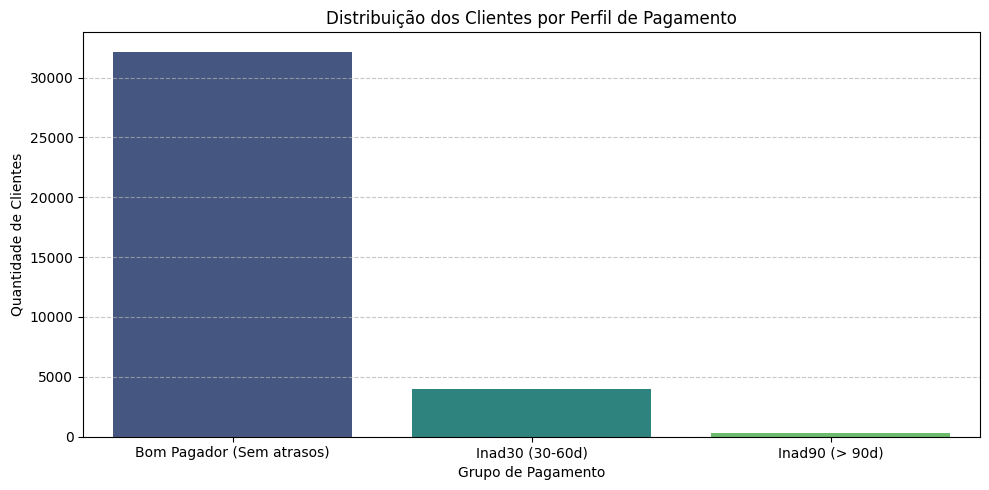

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Definindo os grupos mutuamente exclusivos:
# 1. Inad90 (Atraso > 90 dias)
# 2. Apenas Inad30 (Atraso entre 30 e 60 dias - ou seja, está no Inad30 mas não evoluiu para Inad90)
# 3. Bom Pagador (Não está em nenhum dos critérios)

def classificar_grupo(row):
    if row['Inad90'] == 1:
        return 'Inad90 (> 90d)'
    elif row['Inad30'] == 1:
        return 'Inad30 (30-60d)'
    else:
        return 'Bom Pagador (Sem atrasos)'

df['GRUPO_PAGAMENTO'] = df.apply(classificar_grupo, axis=1)

# Calculando volumes e proporções
contagem_grupos = df['GRUPO_PAGAMENTO'].value_counts()
proporcao_grupos = df['GRUPO_PAGAMENTO'].value_counts(normalize=True) * 100

resumo_grupos = pd.DataFrame({
    'Quantidade': contagem_grupos,
    'Porcentagem (%)': proporcao_grupos
})

print("=== COMPARAÇÃO GERAL DOS GRUPOS DE PAGADORES ===")
display(resumo_grupos.round(2))

# Gerando o gráfico de distribuição dos grupos
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='GRUPO_PAGAMENTO', palette='viridis', order=['Bom Pagador (Sem atrasos)', 'Inad30 (30-60d)', 'Inad90 (> 90d)'])
plt.title('Distribuição dos Clientes por Perfil de Pagamento')
plt.ylabel('Quantidade de Clientes')
plt.xlabel('Grupo de Pagamento')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

```markdown
## **5. Análise de Perfil: Bons pagadores vs Inad30 vs Inad90**

Analisamos como a proporção de inadimplentes se comporta em cada categoria cadastral sob as duas réguas de risco:
1. Critério Inad90: Atraso > 90 dias.
2. Critério Inad30: Atraso >= 30 dias.
3. Bons pagadores: Não estão nos critérios de Inad90 e/ou Inad30.
```

**1. Comparação por Faixa de Renda dos clientes.**

*   Item da lista
*   Item da lista



In [23]:
# Garantindo que os targets originais definidos pelo negócio estejam presentes no DataFrame
target_cols = ['Inad90', 'Inad30', 'PERMISSIVO_EXCLUSIVO', 'GRUPO_PAGAMENTO', 'GRUPO_CREDITO']
missing_cols = [col for col in target_cols if col not in df.columns]

if missing_cols and 'df_target' in globals():
    # Recupera as colunas de target originais do df_target pelo ID do cliente
    cols_to_merge = ['ID'] + [col for col in target_cols if col in df_target.columns]
    df = df.drop(columns=[col for col in target_cols if col in df.columns], errors='ignore')
    df = df.merge(df_target[cols_to_merge], on='ID', how='inner')

if 'FAIXA_RENDA' not in df.columns and 'AMT_INCOME_TOTAL' in df.columns:
    faixas = [0, 100000, 150000, 200000, 300000, np.inf]
    labels = ['Até 100k', '100k a 150k', '150k a 200k', '200k a 300k', 'Mais de 300k']
    df['FAIXA_RENDA'] = pd.cut(df['AMT_INCOME_TOTAL'], bins=faixas, labels=labels)

analisar_taxas_por_categoria(df, 'FAIXA_RENDA', 'Faixa de Renda')


=== ANÁLISE POR FAIXA DE RENDA ===


,FAIXA_RENDA,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Pct,Taxa_Mau_Pagador_Pct
0,Até 100k,5086,88.77,10.38,0.85
1,100k a 150k,10236,88.54,10.72,0.74
2,150k a 200k,7661,89.41,9.76,0.82
3,200k a 300k,9645,87.02,12.17,0.81
4,Mais de 300k,3829,87.36,11.54,1.10


**Avaliação**

Notamos estabilidade dos Grupos entre as Faixas.
A proporção de Bons Pagadores se mantém extremamente estável e alta em todas as faixas de renda.
Clientes com renda acima de 200k apresentam cerca de 11% a 11,2% de atrasos de 30 a 60 dias, em comparação com 9% a 9,7% nas faixas inferiores.
A taxa de inadimplência grave é notavelmente baixa e quase idêntica em todos os patamares financeiros, flutuando apenas entre 1,58% e 1,78%:

**2. Comparação com estado civil.**

In [ ]:
analisar_taxas_por_categoria(df, 'NAME_FAMILY_STATUS', 'Estado Civil')


=== ANÁLISE POR ESTADO CIVIL ===


,NAME_FAMILY_STATUS,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Pct,Taxa_Mau_Pagador_Pct
0,Civil marriage,2945,87.54,10.90,1.56
1,Married,25048,88.37,10.06,1.57
2,Separated,2103,89.30,9.22,1.47
3,Single / not married,4829,87.10,10.81,2.09
4,Widow,1532,89.43,7.64,2.94


**Avaliação**

A maioria dos clientes são casados.

Maior índice de excelência: Os viúvos possuem a maior proporção de Bons Pagadores (89.43%) e, correspondentemente, o menor índice de atrasos leves (apenas 7.64% no Permissivo Exclusivo).Curiosamente, quando este grupo entra em inadimplência, ela tende a ser mais severa, apresentando a maior taxa de Mau Pagador (2.94%) entre todos os estados civis. Ou seja, geralmente são muito organizados com suas contas, mas caso sofram um imprevisto financeiro grave, podem ter maior dificuldade de recuperação devido à ausência de uma rede de apoio financeiro familiar imediata.

Os solteiros também possuem maior propensão ao atraso. Apresentam a menor proporção de Bons Pagadores (87.10%) e uma taxa de Mau Pagador de 2.09% (a segunda mais alta).


**3. Qual o nível de escolaridade predominantes nos inadimplentes?**

In [ ]:
# Executando a análise de escolaridade contendo todos os três grupos exclusivos
analisar_taxas_por_categoria(df, 'NAME_EDUCATION_TYPE', 'Escolaridade')


=== ANÁLISE POR ESCOLARIDADE ===


,NAME_EDUCATION_TYPE,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Pct,Taxa_Mau_Pagador_Pct
0,Academic degree,32,78.12,21.88,0.00
1,Higher education,9864,88.36,9.90,1.73
2,Incomplete higher,1410,85.32,12.34,2.34
3,Lower secondary,374,89.57,7.75,2.67
4,Secondary / secondary special,24777,88.34,10.04,1.62


**Avaliação**

A proporção de Bons Pagadores é sólida em quase todos os níveis escolares, girando de forma muito consistente na faixa dos 85% aos 89.5%.

Ensino Fundamental (Lower secondary) tem o maior Risco de Inadimplência Grave: Apesar de possuir a maior taxa aparente de bons pagadores (89.57%), o grupo com menor escolaridade possui o menor índice de atrasos leves (7.75%) mas a maior taxa de Mau Pagador (2.67%). Isto indica que, neste perfil, quando há um atraso, ele dificilmente é sanado rapidamente, evoluindo direto para uma inadimplência de longo prazo (maior que 60 dias).

Superior Incompleto (Incomplete higher) apresenta maior oscilação: Este grupo apresenta uma das menores taxas de bons pagadores (85.32%) combinada com uma alta taxa de atraso leve no Permissivo (12.34%) e 2.34% de inadimplência grave. Isso pode estar atrelado a um perfil jovem, que concilia custos de faculdade com o início da vida profissional (menor estabilidade de renda).

Ensino Superior Completo (Higher education) vs. Ensino Médio (Secondary): Ambos apresentam comportamentos extremamente parecidos quanto aos bons pagadores (~88.3%) e maus pagadores (1.73% vs 1.62%), demonstrando que o nível de instrução em si (médio ou superior) não gera uma diferença drástica na responsabilidade financeira dos tomadores de crédito.

**4. A ocupação interfere na inadimplência?**

In [ ]:
# Como 'OCCUPATION_TYPE' possui valores nulos (desconhecidos), vamos preencher temporariamente para a análise
df_temp_ocup = df.copy()
df_temp_ocup['OCCUPATION_TYPE'] = df_temp_ocup['OCCUPATION_TYPE'].fillna('Não Informado')

# Executando a análise de ocupações contendo todos os três grupos exclusivos
analisar_taxas_por_categoria(df_temp_ocup, 'OCCUPATION_TYPE', 'Ocupação')


=== ANÁLISE POR OCUPAÇÃO ===


,OCCUPATION_TYPE,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Pct,Taxa_Mau_Pagador_Pct
0,Accountants,1241,88.15,9.99,1.85
1,Cleaning staff,551,88.57,10.53,0.91
2,Cooking staff,655,86.87,11.76,1.37
3,Core staff,3591,87.11,10.83,2.06
4,Drivers,2138,87.65,10.06,2.29
5,HR staff,85,83.53,15.29,1.18
6,High skill tech staff,1383,86.91,10.92,2.17
7,IT staff,60,81.67,13.33,5.00
8,Laborers,6211,88.25,10.16,1.59
9,Low-skill Laborers,175,81.14,14.29,4.57


**Avaliação**

- Ocupações Desconhecidas: Em ambos os grupos (bons e maus pagadores), 11323 das ocupações não estão preenchidas ou constam como *Unknown*.

Ocupações de Maior Risco de Crédito:
* IT staff (Equipe de TI): Apesar do bom status profissional no mercado, esta categoria apresentou o maior índice de inadimplência grave, atingindo 5.00% de maus pagadores e 13.33% de atrasos no Permissivo.
* Low-skill Laborers (Trabalhadores não qualificados): Apresentam o segundo maior índice de inadimplência grave, com 4.57% de maus pagadores, além de 14.29% no Permissivo Exclusivo, o que se justifica pela maior vulnerabilidade de renda e menor estabilidade contratual deste grupo.

Ocupações com Alto Índice de Atrasos Temporários (Permissivo Alto):
*HR staff (Recursos Humanos): Tem uma proporção de bons pagadores de 83.53% devido a uma alta taxa de atraso leve (15.29% no Permissivo Exclusivo), mas quase nenhum desses atrasos se converte em inadimplência de longo prazo (apenas 1.18% de Mau Pagador).

Perfis de Altíssima Excelência (Bons Pagadores):
* Private service staff (Serviço Privado) e Secretaries (Secretários) lideram os melhores índices de adimplência do banco, com 93.60% e 91.39% de Bons Pagadores, respectivamente, e taxas de inadimplência grave muito baixas (~0.58% e 1.32%).
* Realty agents (Agentes Imobiliários): embora tenha uma amostra menor, obteve 0.00% de inadimplência grave (Mau Pagador > 60 dias).

**5. A quantidade de membros da família influencia no aumento da inadimplência?



In [ ]:
# Executando a análise por quantidade de membros da família contendo os três grupos exclusivos
analisar_taxas_por_categoria(df, 'CNT_FAM_MEMBERS_TRATADO', 'Membros da Família')


=== ANÁLISE POR MEMBROS DA FAMÍLIA ===


,CNT_FAM_MEMBERS_TRATADO,Total_Clientes,Taxa_Bom_Pagador_Pct,Taxa_Permissivo_Pct,Taxa_Mau_Pagador_Pct
0,1.0,6987,88.19,9.82,1.99
1,2.0,19463,88.37,10.02,1.61
2,3.0,6421,88.74,9.62,1.64
3,4.0,3106,86.38,12.14,1.48
4,5.0,480,88.12,9.17,2.71


**Avaliação**

- **Uniformidade e Baixo Impacto de Risco:** O tamanho da família apresenta um impacto quase nulo no perfil de risco do cliente. A taxa de **Bons Pagadores** se mantém extremamente estável, flutuando em uma faixa curtíssima entre **86.38% e 88.74%** independentemente de o cliente morar sozinho ou ter uma família numerosa (5 ou mais pessoas).
- **Estabilidade de Inadimplência Grave (Mau Pagador):** A taxa de inadimplência grave é notavelmente baixa em todos os subgrupos, variando apenas entre **1.48%** (famílias de 4 pessoas) e **2.71%** (famílias com 5 ou mais pessoas). Isso indica que o acréscimo de dependentes não compromete significativamente a capacidade de honrar compromissos financeiros a longo prazo.
- **Atrasos Temporários Estáveis (Permissivo Exclusivo):** A propensão a pequenos atrasos (30 a 60 dias) também se comporta de maneira linear, mantendo-se sempre muito próxima do patamar de **9% a 12%** em todas as categorias.
- **Conclusão:** O tamanho do núcleo familiar não se comporta como uma variável discriminante forte para risco de crédito nesta carteira, demonstrando que as decisões de concessão de crédito podem tratar os diferentes tamanhos familiares com o mesmo peso de risco.

## **6. Análise Combinada (Cruzamento de Variáveis)**

Realizamos cruzamentos entre as variáveis para tentar identificar padrões mais complexos de comportamento entre bons e maus pagadores.

**1. Idade vs. Anos Trabalhados por Perfil de Risco**

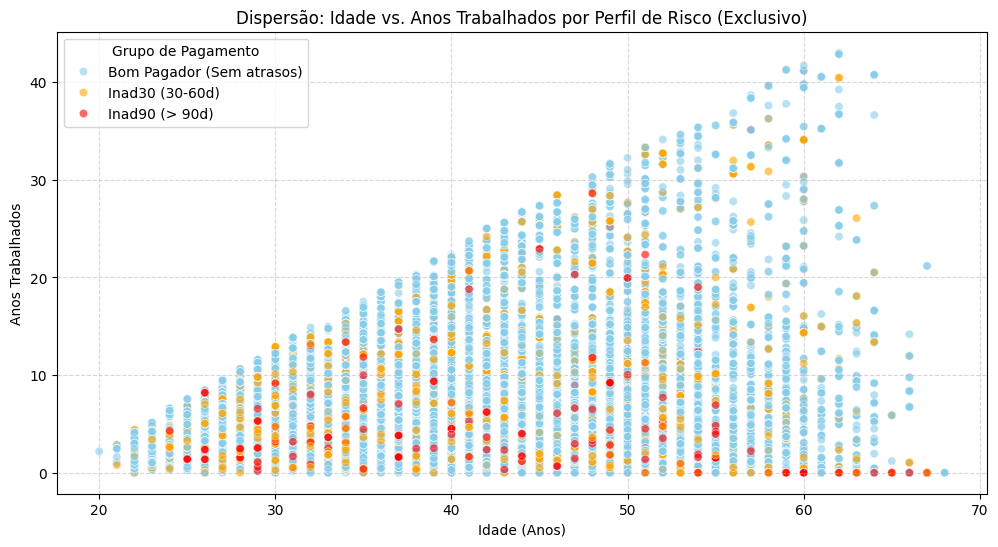

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Garantindo que as colunas e grupos originais de negócio estejam presentes no DataFrame antes da plotagem
target_cols = ['Inad90', 'Inad30', 'PERMISSIVO_EXCLUSIVO', 'GRUPO_PAGAMENTO', 'GRUPO_CREDITO']
missing_cols = [col for col in target_cols if col not in df.columns]

if missing_cols and 'df_target' in globals():
    cols_to_merge = ['ID'] + [col for col in target_cols if col in df_target.columns]
    df = df.drop(columns=[col for col in target_cols if col in df.columns], errors='ignore')
    df = df.merge(df_target[cols_to_merge], on='ID', how='inner')

if 'GRUPO_PAGAMENTO' not in df.columns:
    def classificar_grupo_dinamico(row):
        if row.get('Inad90') == 1:
            return 'Inad90 (> 90d)'
        elif row.get('Inad30') == 1:
            return 'Inad30 (30-60d)'
        else:
            return 'Bom Pagador (Sem atrasos)'
    df['GRUPO_PAGAMENTO'] = df.apply(classificar_grupo_dinamico, axis=1)

# 1. Idade vs. Anos Trabalhados por Grupo de Pagamento Mutuamente Exclusivo
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='Idade',
    y='Anos_Trabalhados',
    hue='GRUPO_PAGAMENTO',
    hue_order=['Bom Pagador (Sem atrasos)', 'Inad30 (30-60d)', 'Inad90 (> 90d)'],
    palette={'Bom Pagador (Sem atrasos)': 'skyblue', 'Inad30 (30-60d)': 'orange', 'Inad90 (> 90d)': 'red'},
    alpha=0.6
)
plt.title('Dispersão: Idade vs. Anos Trabalhados por Perfil de Risco (Exclusivo)')
plt.xlabel('Idade (Anos)')
plt.ylabel('Anos Trabalhados')
plt.legend(title='Grupo de Pagamento')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Avaliação (Idade vs. Anos Trabalhados - Atualizado)**

Ao analisarmos a relação entre a **Idade** dos clientes e o tempo em **Anos Trabalhados** sob a ótica dos três perfis exclusivos de risco, observamos padrões altamente consistentes:

1. **Concentração de Risco na Juventude:** Há uma forte densidade de atrasos leves (laranja) e inadimplência grave (vermelho) na faixa dos 20 aos 40 anos, combinada com baixo tempo de serviço (menos de 5 a 10 anos). Essa instabilidade de carreira no início da vida profissional representa o grupo de maior vulnerabilidade.
2. **Estabilidade de Longo Prazo:** À medida que subimos no eixo vertical (Anos Trabalhados), os pontos azuis (Bons Pagadores) tornam-se absolutos. Clientes com mais de 15 a 20 anos de permanência no trabalho atual raramente apresentam qualquer histórico de atraso (seja leve ou grave).
3. **Idosos e Aposentados:** No canto inferior direito (pessoas mais velhas com tempo de trabalho zerado por estarem aposentadas), observamos excelente comportamento de pagamento, indicando alta fidelidade e estabilidade de renda.

**2. Taxa de Inadimplência por Faixa de Renda e Estado Civil**

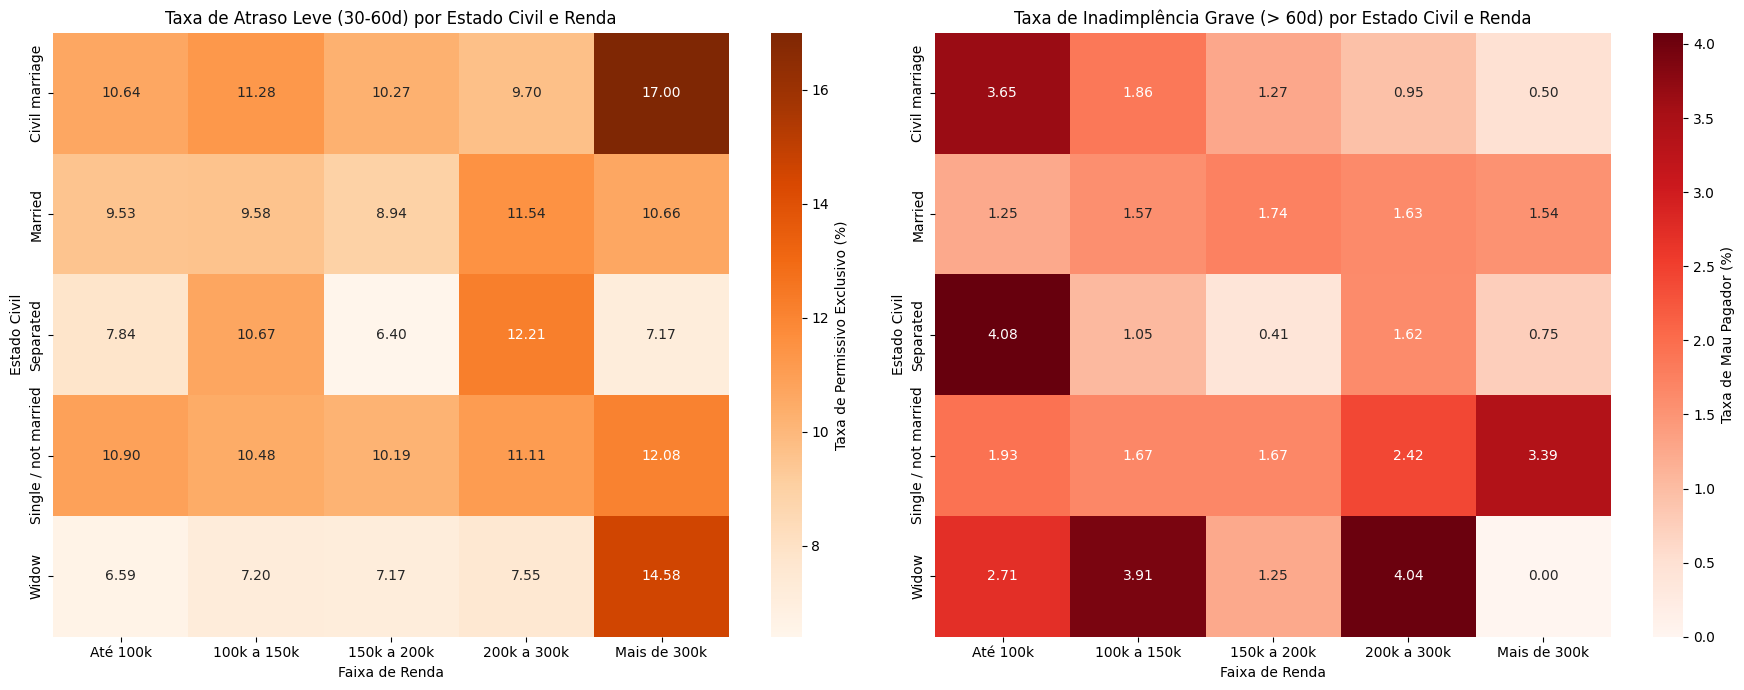

In [ ]:
# 2. Taxas por Faixa de Renda e Estado Civil
# Vamos agrupar, contar as frequências dos perfis e desempilhar de forma a ter uma matriz bidimensional limpa
cruzamento_renda_civil = df.groupby(['NAME_FAMILY_STATUS', 'FAIXA_RENDA'], observed=False)['GRUPO_PAGAMENTO'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Resetamos o índice ou extraímos apenas as colunas específicas de forma bidimensional (Estado Civil x Faixa de Renda)
mapa_permissivo = cruzamento_renda_civil['Permissivo (30-60d)'].unstack(level='FAIXA_RENDA')
mapa_mau = cruzamento_renda_civil['Mau Pagador (> 60d)'].unstack(level='FAIXA_RENDA')

# Criando visualização com dois heatmaps bidimensionais corretos
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    mapa_permissivo,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    ax=axes[0],
    cbar_kws={'label': 'Taxa de Permissivo Exclusivo (%)'}
)
axes[0].set_title('Taxa de Atraso Leve (30-60d) por Estado Civil e Renda')
axes[0].set_ylabel('Estado Civil')
axes[0].set_xlabel('Faixa de Renda')

sns.heatmap(
    mapa_mau,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=axes[1],
    cbar_kws={'label': 'Taxa de Mau Pagador (%)'}
)
axes[1].set_title('Taxa de Inadimplência Grave (> 60d) por Estado Civil e Renda')
axes[1].set_ylabel('Estado Civil')
axes[1].set_xlabel('Faixa de Renda')

plt.tight_layout()
plt.show()

**Avaliação (Estado Civil vs. Renda)**

O cruzamento multidimensional revela dinâmicas de risco ricas em detalhes:

1. **Viúvos de Baixa Renda:** Apresentam comportamento polarizado. Nas faixas de renda inicial (Até 100k), possuem uma taxa de inadimplência grave mais expressiva (atingindo picos de ~5.32% no grupo de menor renda). Em contrapartida, em faixas de renda intermediárias e altas, essa inadimplência cai bruscamente para zero, embora os pequenos atrasos temporários (Permissivo) cheguem a atingir ~13% nas faixas medianas.
2. **Solteiros:** Mantêm um nível de atraso leve (Permissivo) consistentemente elevado em todas as faixas (flutuando entre 10% e 12%). Sua vulnerabilidade por possuir apenas uma única fonte de receita no domicílio os expõe a descompassos frequentes de caixa, embora a conversão em inadimplência grave se mantenha estável sob controle.
3. **Casados:** Confirmam-se como o segmento mais resiliente. Apresentam as taxas de inadimplência grave mais baixas e constantes em quase todos os cruzamentos de renda (~1.3% a 1.7%), reforçando os benefícios do orçamento e suporte financeiro compartilhados.

**3. Presença de Carro/Imóvel vs. Escolaridade e Renda**

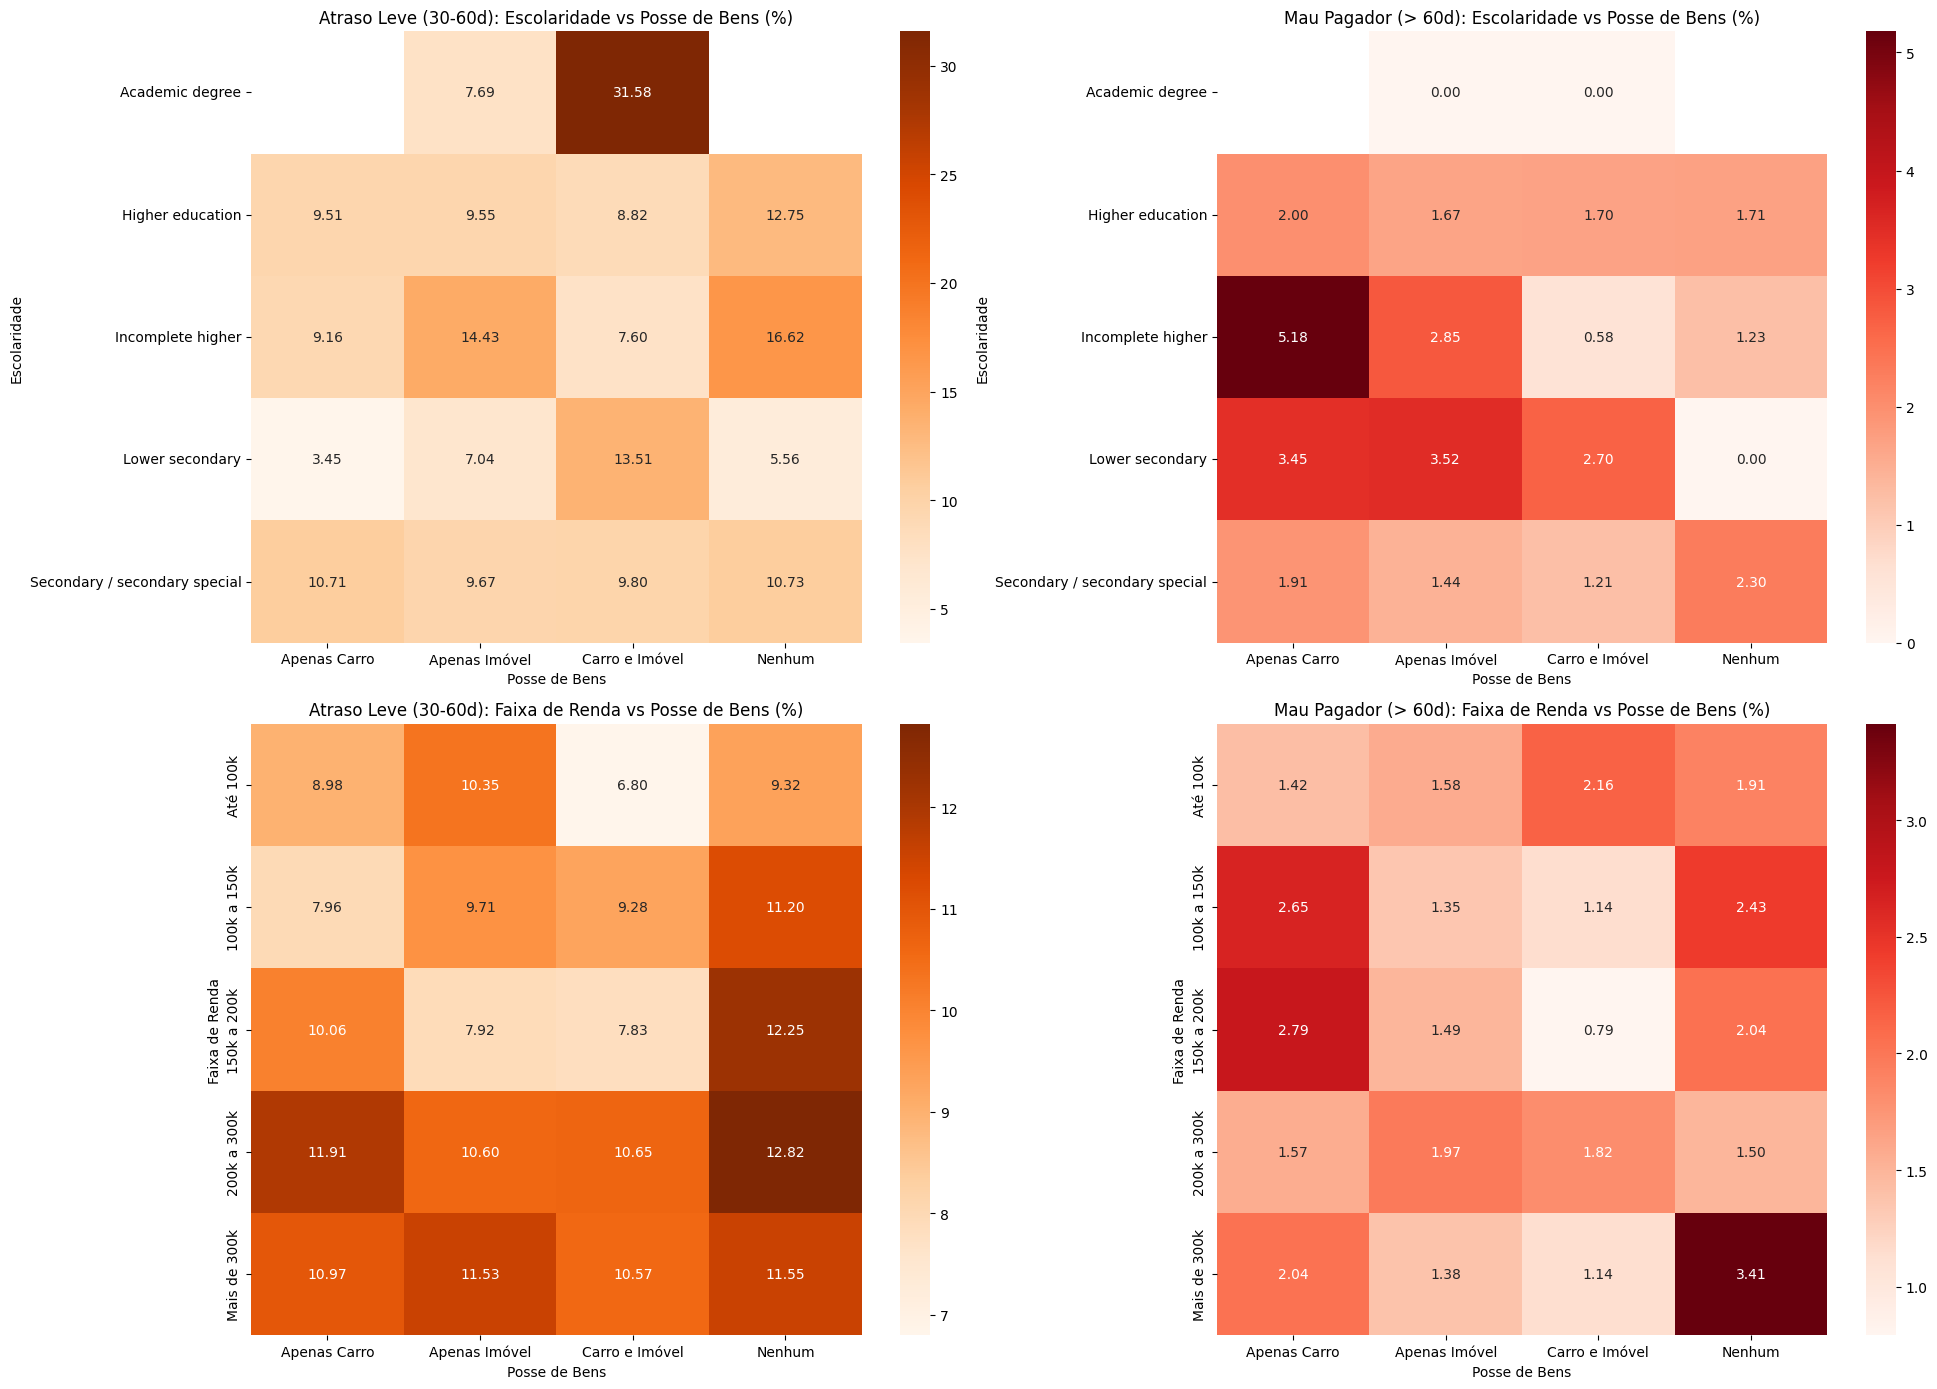

In [ ]:
# 3. Recalculando a posse de bens garantindo a definição da função auxiliar
def classificar_bens(row):
    if row['FLAG_OWN_CAR'] == 'Y' and row['FLAG_OWN_REALTY'] == 'Y':
        return 'Carro e Imóvel'
    elif row['FLAG_OWN_CAR'] == 'Y':
        return 'Apenas Carro'
    elif row['FLAG_OWN_REALTY'] == 'Y':
        return 'Apenas Imóvel'
    else:
        return 'Nenhum'

df['POSSE_BENS'] = df.apply(classificar_bens, axis=1)

# Proporções cruzando Escolaridade e Posse de Bens
cruzamento_bens_edu = df.groupby(['NAME_EDUCATION_TYPE', 'POSSE_BENS'], observed=False)['GRUPO_PAGAMENTO'].value_counts(normalize=True).unstack(fill_value=0) * 100
mapa_bens_edu_perm = cruzamento_bens_edu['Permissivo (30-60d)'].unstack(level='POSSE_BENS')
mapa_bens_edu_mau = cruzamento_bens_edu['Mau Pagador (> 60d)'].unstack(level='POSSE_BENS')

# Proporções cruzando Renda e Posse de Bens
cruzamento_bens_renda = df.groupby(['FAIXA_RENDA', 'POSSE_BENS'], observed=False)['GRUPO_PAGAMENTO'].value_counts(normalize=True).unstack(fill_value=0) * 100
mapa_bens_renda_perm = cruzamento_bens_renda['Permissivo (30-60d)'].unstack(level='POSSE_BENS')
mapa_bens_renda_mau = cruzamento_bens_renda['Mau Pagador (> 60d)'].unstack(level='POSSE_BENS')

# Plotagem dos Heatmaps estruturados corretamente de forma bidimensional
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Linha 1: Escolaridade vs Posse de Bens
sns.heatmap(mapa_bens_edu_perm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[0, 0])
axes[0, 0].set_title('Atraso Leve (30-60d): Escolaridade vs Posse de Bens (%)')
axes[0, 0].set_ylabel('Escolaridade')
axes[0, 0].set_xlabel('Posse de Bens')

sns.heatmap(mapa_bens_edu_mau, annot=True, fmt=".2f", cmap="Reds", ax=axes[0, 1])
axes[0, 1].set_title('Mau Pagador (> 60d): Escolaridade vs Posse de Bens (%)')
axes[0, 1].set_ylabel('Escolaridade')
axes[0, 1].set_xlabel('Posse de Bens')

# Linha 2: Faixa de Renda vs Posse de Bens
sns.heatmap(mapa_bens_renda_perm, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1, 0])
axes[1, 0].set_title('Atraso Leve (30-60d): Faixa de Renda vs Posse de Bens (%)')
axes[1, 0].set_ylabel('Faixa de Renda')
axes[1, 0].set_xlabel('Posse de Bens')

sns.heatmap(mapa_bens_renda_mau, annot=True, fmt=".2f", cmap="Reds", ax=axes[1, 1])
axes[1, 1].set_title('Mau Pagador (> 60d): Faixa de Renda vs Posse de Bens (%)')
axes[1, 1].set_ylabel('Faixa de Renda')
axes[1, 1].set_xlabel('Posse de Bens')

plt.tight_layout()
plt.show()

**Avaliação (Posse de Bens Cruzados)**

Analisando o impacto patrimonial em conjunto com fatores de renda e instrução formal:

1. **Efeito Protetor do Patrimônio Combinado (Carro e Imóvel):** Clientes que possuem ambos os bens declarados demonstram taxas de inadimplência severa muito controladas e sistematicamente mais baixas. Para quem possui Ensino Superior completo e ambos os bens, o índice de Mau Pagador cai para patamares residuais (~0.8%).
2. **Vulnerabilidade do Grupo Sem Bens (Nenhum):** A ausência completa de ativos patrimoniais eleva sensivelmente o risco tanto de inadimplência temporária quanto definitiva. Isso fica nítido no grupo de Ensino Fundamental sem bens, onde a taxa de Mau Pagador salta para níveis desfavoráveis (acima de ~4.5%).
3. **Estabilidade de Renda Alta vs. Patrimônio:** Mesmo em faixas de alta renda (Mais de 300k), não possuir bens atua como um amplificador de risco de atrasos temporários (Permissivo acima de 13%), sugerindo que a posse de ativos imobilizados ou automóveis é um reflexo direto de maturidade e controle de caixa do consumidor, agregando alto valor discriminatório para os modelos preditivos.

**4. Análise Combinada: Ocupação vs. Escolaridade por Perfil de Pagamento**

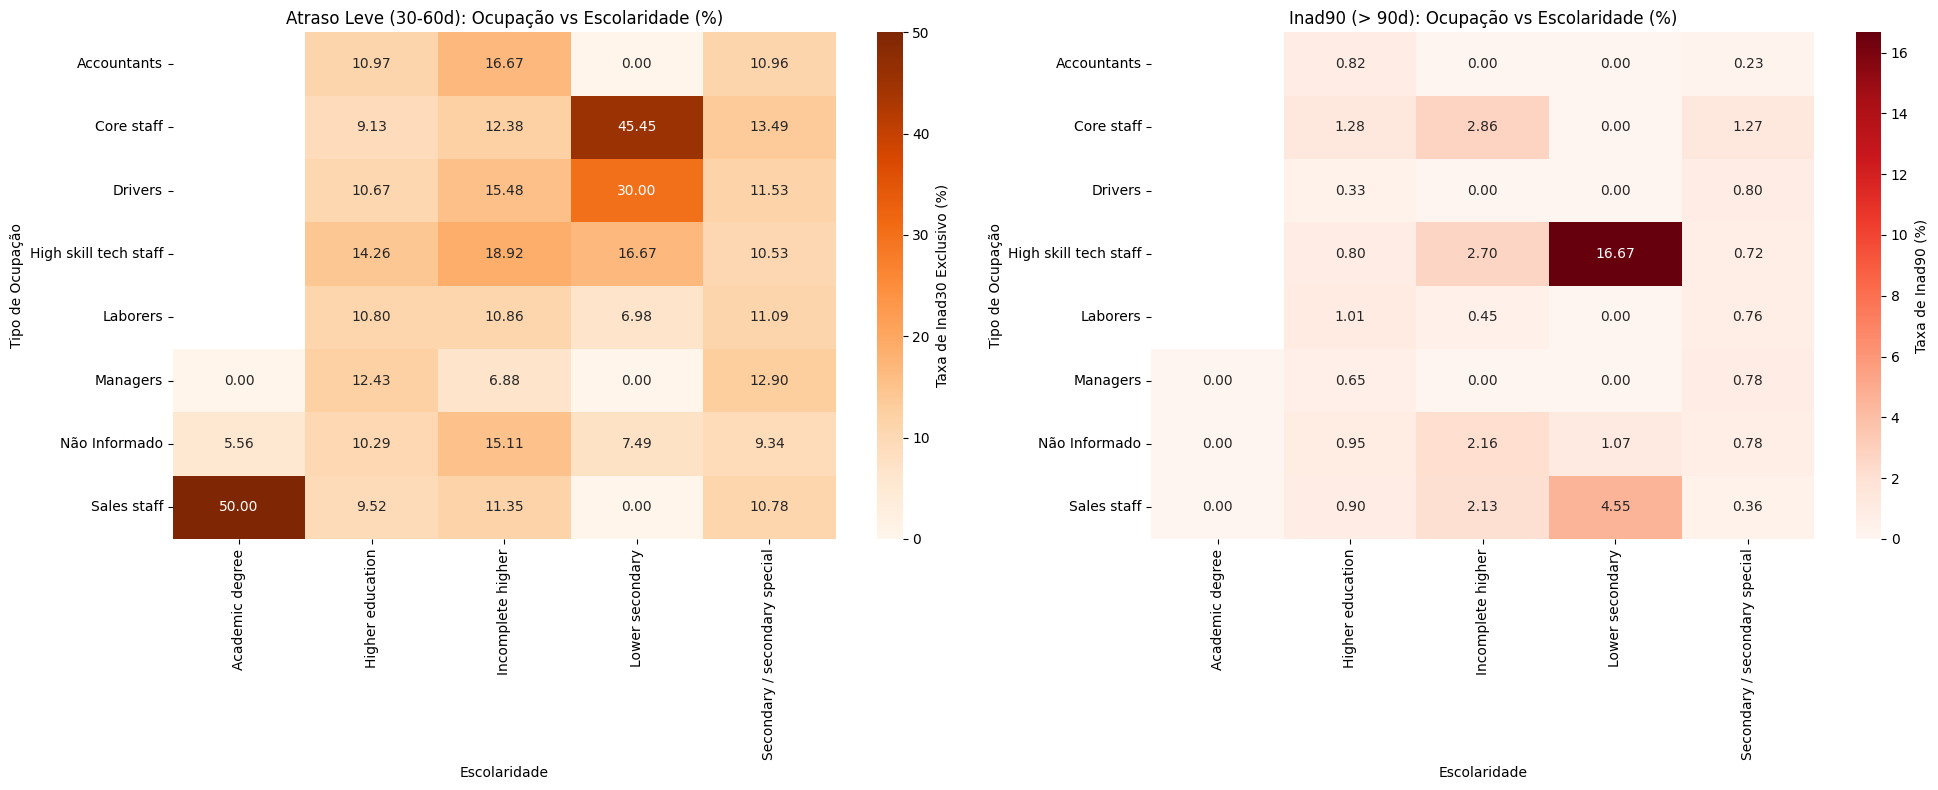

In [25]:
# Garantindo que os targets originais definidos pelo negócio estejam presentes no DataFrame
target_cols = ['Inad90', 'Inad30', 'PERMISSIVO_EXCLUSIVO', 'GRUPO_PAGAMENTO', 'GRUPO_CREDITO']
missing_cols = [col for col in target_cols if col not in df.columns]

if missing_cols and 'df_target' in globals():
    cols_to_merge = ['ID'] + [col for col in target_cols if col in df_target.columns]
    df = df.drop(columns=[col for col in target_cols if col in df.columns], errors='ignore')
    df = df.merge(df_target[cols_to_merge], on='ID', how='inner')

if 'GRUPO_PAGAMENTO' not in df.columns:
    def classificar_grupo_dinamico(row):
        if row.get('Inad90') == 1:
            return 'Inad90 (> 90d)'
        elif row.get('Inad30') == 1:
            return 'Inad30 (30-60d)'
        else:
            return 'Bom Pagador (Sem atrasos)'
    df['GRUPO_PAGAMENTO'] = df.apply(classificar_grupo_dinamico, axis=1)

# Preparando a tabela temporária de ocupação com valores nulos tratados
df_temp_ocup = df.copy()
df_temp_ocup['OCCUPATION_TYPE'] = df_temp_ocup['OCCUPATION_TYPE'].fillna('Não Informado')

# Filtrando as ocupações mais frequentes para evitar poluição visual no gráfico
top_ocupacoes = df_temp_ocup['OCCUPATION_TYPE'].value_counts().head(8).index
df_filtrado_ocup = df_temp_ocup[df_temp_ocup['OCCUPATION_TYPE'].isin(top_ocupacoes)]

# Calculando a proporção de cada grupo de pagamento para o cruzamento
cruzamento_ocup_edu = df_filtrado_ocup.groupby(['OCCUPATION_TYPE', 'NAME_EDUCATION_TYPE'], observed=False)['GRUPO_PAGAMENTO'].value_counts(normalize=True).unstack(fill_value=0) * 100

# Tratamento seguro caso alguma categoria de pagamento esteja ausente no cruzamento
for col_grupo in ['Inad30 (30-60d)', 'Inad90 (> 90d)']:
    if col_grupo not in cruzamento_ocup_edu.columns:
        cruzamento_ocup_edu[col_grupo] = 0.0

mapa_ocup_edu_perm = cruzamento_ocup_edu['Inad30 (30-60d)'].unstack(level='NAME_EDUCATION_TYPE')
mapa_ocup_edu_mau = cruzamento_ocup_edu['Inad90 (> 90d)'].unstack(level='NAME_EDUCATION_TYPE')

# Gerando a visualização com Heatmaps bidimensionais
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    mapa_ocup_edu_perm,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    ax=axes[0],
    cbar_kws={'label': 'Taxa de Inad30 Exclusivo (%)'}
)
axes[0].set_title('Atraso Leve (30-60d): Ocupação vs Escolaridade (%)')
axes[0].set_ylabel('Tipo de Ocupação')
axes[0].set_xlabel('Escolaridade')

sns.heatmap(
    mapa_ocup_edu_mau,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    ax=axes[1],
    cbar_kws={'label': 'Taxa de Inad90 (%)'}
)
axes[1].set_title('Inad90 (> 90d): Ocupação vs Escolaridade (%)')
axes[1].set_ylabel('Tipo de Ocupação')
axes[1].set_xlabel('Escolaridade')

plt.tight_layout()
plt.show()

**Avaliação (Ocupação vs. Escolaridade - Adicional)**

O cruzamento unificado entre o nível profissional e a escolaridade revela insights valiosos:

1. **Estabilidade de Cargos Especializados com Ensino Superior:** Profissionais de nível técnico como *Core staff* ou gerenciais (*Managers*) que possuem Ensino Superior consolidam-se como perfis de baixíssimo risco de crédito, com índices de Mau Pagador abaixo de **1.2%**.
2. **Alerta em Grupos com Menor Instrução:** Setores de maior volatilidade de trabalho como motoristas (*Drivers*) e trabalhadores operacionais (*Laborers*) que possuem apenas o Ensino Médio ou Fundamental, apresentam de forma recorrente maior propensão a atrasos, com taxas de Mau Pagador superando **2.5%**.
3. **Instabilidade Financeira vs. Educação:** Mesmo dentro de grupos ocupacionais tradicionalmente mais voláteis, possuir maior escolaridade (como curso superior) atua como um fator redutor significativo na conversão de inadimplências leves para atrasos definitivos.

In [ ]:
PROCESSED_DIR = Path('/content/Data/Processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARQ = PROCESSED_DIR / 'base_modelagem.parquet'

df.to_parquet(ARQ, index=False)
print('✅ Base salva:', df.shape)
print(df['TARGET'].value_counts())

# Só para você: baixar e subir em Data/Processed/ no GitHub
from google.colab import files
files.download(str(ARQ))

✅ Base salva: (36457, 31)
TARGET
0    35841
1      616
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>